# EDA Ecobici

### Verificar cómo se está guardando el cicloestacionretiro
Sale como valor no numérico en el ingest.py

In [30]:
import sys
sys.path.append("../src")
import pandas as pd
import glob

paths = sorted(glob.glob("../data/raw/*.csv"))
print(paths)

frames = [pd.read_csv(p, low_memory=False) for p in paths]
raw = pd.concat(frames, ignore_index=True)
raw.columns = [c.strip().lower().replace("_", "").replace(" ", "") for c in raw.columns]

for col in ["cicloestacionretiro", "cicloestacionarribo"]:
    vals = raw[col].astype(str)
    no_numericos = vals[~vals.str.match(r"^\d+$")]
    print(f"\n--- {col}: {len(no_numericos)} valores no numéricos ---")
    print(no_numericos.value_counts().head(20))

['../data/raw/2026-05.csv', '../data/raw/2026-06.csv']

--- cicloestacionretiro: 109824 valores no numéricos ---
cicloestacionretiro
271-272       20290
237-238       15771
158-159       11743
192-193        9876
107-108        9845
266-267        9237
273-274        9050
390-391        8939
235-236        5501
268-269        4474
445-446        2706
264-275        2145
Temporal 2      119
Temporal 1      106
Temporal 3       16
Temporal 4        6
Name: count, dtype: int64

--- cicloestacionarribo: 123965 valores no numéricos ---
cicloestacionarribo
271-272       35139
266-267       11868
158-159       11867
237-238       11744
273-274       11476
107-108        9630
192-193        8202
390-391        7588
235-236        5600
268-269        4612
264-275        3275
445-446        2659
Temporal 2      145
Temporal 1      106
Temporal 3       29
Temporal 4       25
Name: count, dtype: int64


### Verificar que los registros de estaciones siguen un patrón

In [31]:
stations = pd.read_csv("../data/processed/stations.csv", dtype={"station_id": "string"})
ids_validos = set(stations["station_id"])

pares = ["271-272", "237-238", "158-159", "192-193", "107-108",
         "266-267", "273-274", "390-391", "235-236", "268-269", "445-446"]

for par in pares:
    a, b = par.split("-")
    print(f"{par}: ¿{a} existe? {a in ids_validos} | ¿{b} existe? {b in ids_validos}")

271-272: ¿271 existe? True | ¿272 existe? True
237-238: ¿237 existe? True | ¿238 existe? True
158-159: ¿158 existe? True | ¿159 existe? True
192-193: ¿192 existe? True | ¿193 existe? True
107-108: ¿107 existe? True | ¿108 existe? True
266-267: ¿266 existe? True | ¿267 existe? True
273-274: ¿273 existe? True | ¿274 existe? False
390-391: ¿390 existe? True | ¿391 existe? True
235-236: ¿235 existe? True | ¿236 existe? True
268-269: ¿268 existe? True | ¿269 existe? True
445-446: ¿445 existe? True | ¿446 existe? True


### Verificar la cantidad de viajes largos o cortos

In [32]:
trips = pd.read_parquet("../data/processed/trips_clean.parquet")

muy_cortos = (trips["duracion_min"] < 1).sum()
muy_largos = (trips["duracion_min"] > 45).sum()
total = len(trips)

print(f"Viajes < 1 min: {muy_cortos:,} ({muy_cortos/total:.2%})")
print(f"Viajes > 45 min (límite oficial): {muy_largos:,} ({muy_largos/total:.2%})")

Viajes < 1 min: 374 (0.01%)
Viajes > 45 min (límite oficial): 56,452 (1.82%)


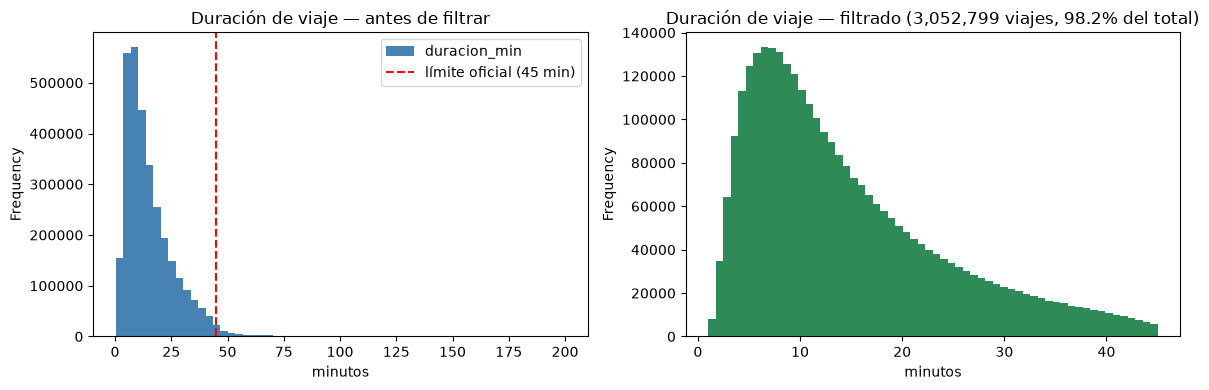

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Antes: distribución completa (se ve dominada por los outliers extremos)
trips["duracion_min"].clip(upper=200).plot.hist(bins=60, ax=axes[0], color="steelblue")
axes[0].axvline(45, color="red", linestyle="--", label="límite oficial (45 min)")
axes[0].set_title("Duración de viaje — antes de filtrar")
axes[0].set_xlabel("minutos")
axes[0].legend()

# Después: solo viajes dentro del rango válido (1-45 min)
validos = trips[(trips["duracion_min"] >= 1) & (trips["duracion_min"] <= 45)]
validos["duracion_min"].plot.hist(bins=60, ax=axes[1], color="seagreen")
axes[1].set_title(f"Duración de viaje — filtrado ({len(validos):,} viajes, {len(validos)/len(trips):.1%} del total)")
axes[1].set_xlabel("minutos")

plt.tight_layout()
plt.savefig("../figures/duracion_antes_despues.png", dpi=150)
plt.show()

## 1. Nulos

In [34]:
trips.isna().mean().sort_values(ascending=False)

estacion_destino         0.039865
estacion_origen          0.035317
edad                     0.000029
bici_id                  0.000000
genero                   0.000000
fecha_origen             0.000000
hora_origen              0.000000
fecha_destino            0.000000
hora_destino             0.000000
origen_dt                0.000000
destino_dt               0.000000
archivo_origen           0.000000
duracion_min             0.000000
hora_del_dia             0.000000
dia_semana               0.000000
fecha                    0.000000
es_fin_de_semana         0.000000
estacion_origen_tipo     0.000000
estacion_destino_tipo    0.000000
dtype: float64

## 2. Outliers de duración

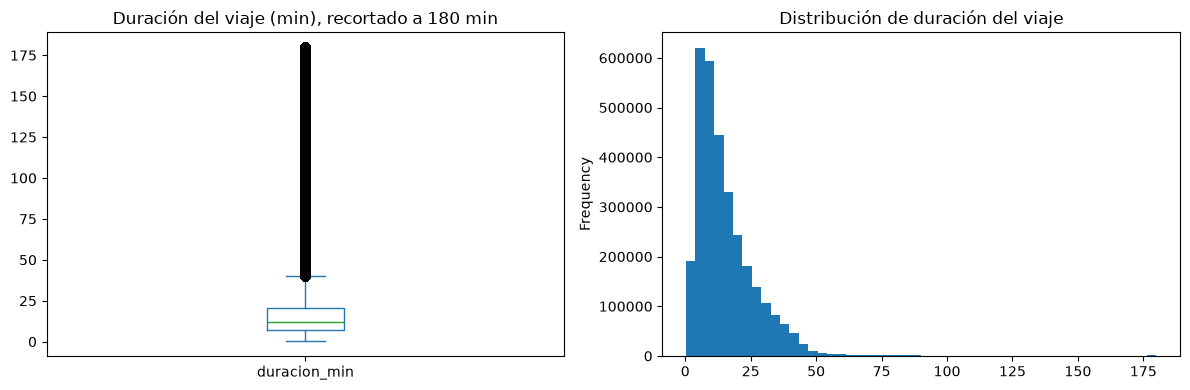

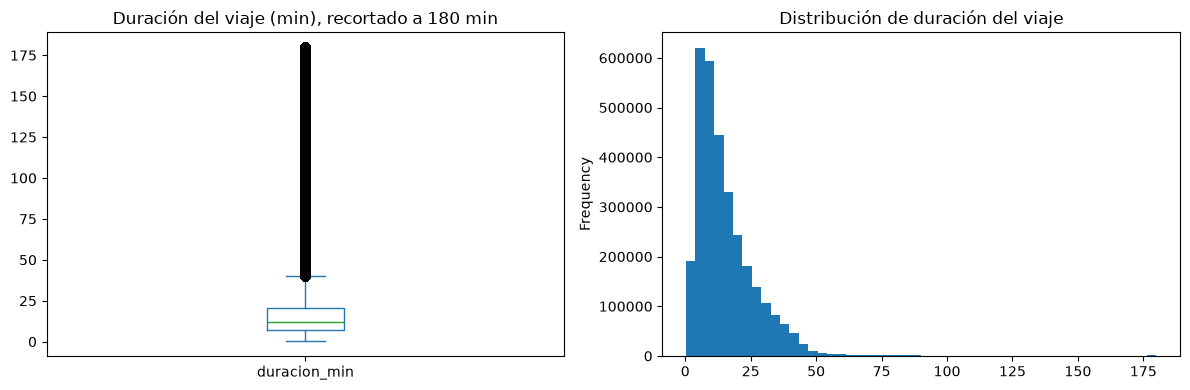

In [35]:
plot_outliers_duracion(trips)

## 3. Viajes por hora del día

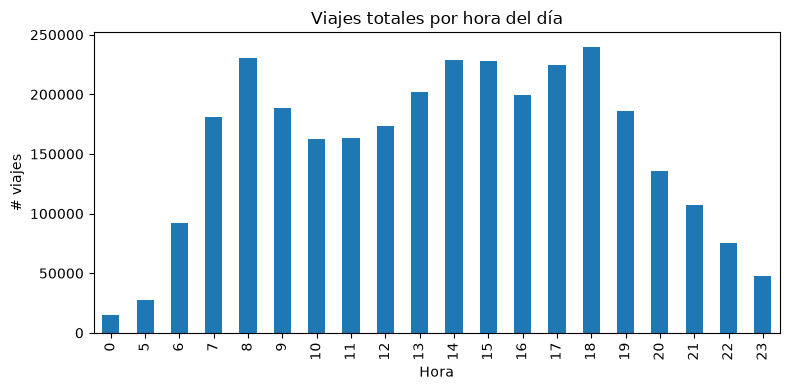

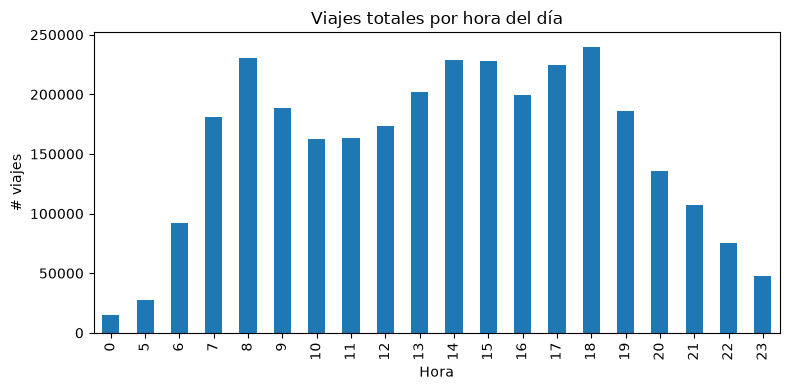

In [36]:
plot_viajes_por_hora(trips)

## 4. Top estaciones por demanda

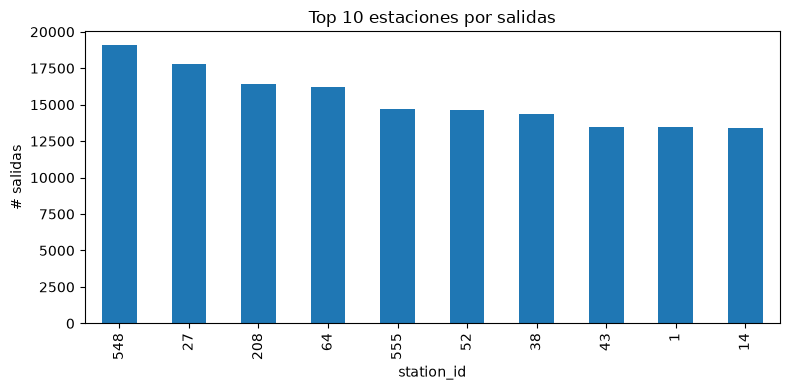

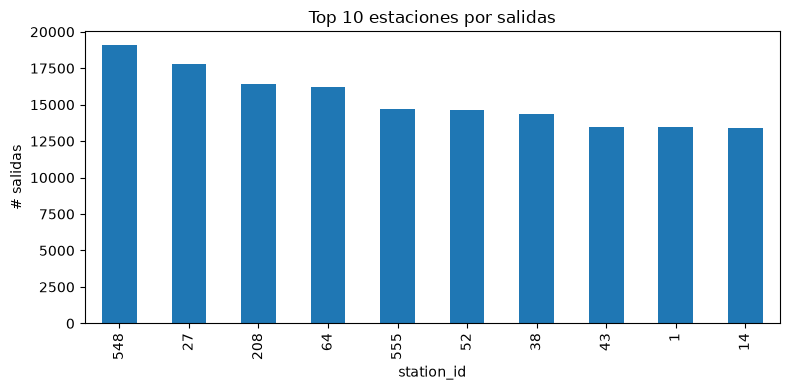

In [37]:
plot_top_estaciones(trips)

## 5. Demanda agregada estacion-fecha-hora (input para el modelo)

In [38]:
demanda = demanda_por_estacion_hora(trips)
demanda.head()

,estacion_origen,fecha,hora_del_dia,salidas
0,1,2026-04-30,23,1
1,1,2026-05-01,5,1
2,1,2026-05-01,6,6
3,1,2026-05-01,7,4
4,1,2026-05-01,8,4


# 6. Top estaciones con actividad

In [39]:
nombres = stations.set_index("station_id")["nombre"]
top10 = validos["estacion_origen"].value_counts().head(10)
top10.index = top10.index.map(nombres)
print(top10)

estacion_origen
CE-652 Xicoténcatl - División del Norte               18858
CE-365 Holbein-Avenida Revolución                     17221
CE-457 Av. Prado Norte-Explanada                      16231
CE-284 Dakota-Vermont                                 15992
CE-571 Manuel M. Flores - Calzada San Antonio Abad    14591
CE-432 Carrillo Puerto-Avenida México-Coyoacan        14171
CE-384 Empresa-Poussin                                14161
CE-710 Molino del Rey - Glorieta de la Lealtad        13275
CE-394 Dr. Roberto Gayol-Félix Cuevas                 12976
CE-367 Boston -Augusto Rodin                          12880
Name: count, dtype: int64[pyarrow]


# 7. Fin de semana vs entre semana

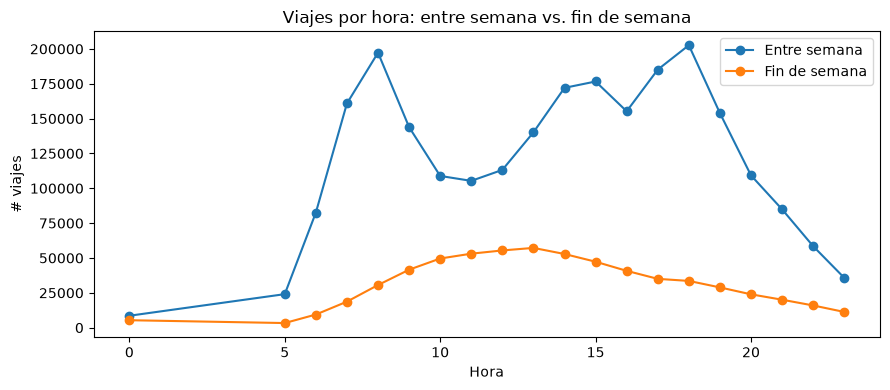

In [40]:
fig, ax = plt.subplots(figsize=(9, 4))
validos[~validos["es_fin_de_semana"]].groupby("hora_del_dia").size().plot(ax=ax, label="Entre semana", marker="o")
validos[validos["es_fin_de_semana"]].groupby("hora_del_dia").size().plot(ax=ax, label="Fin de semana", marker="o")
ax.set_title("Viajes por hora: entre semana vs. fin de semana")
ax.set_xlabel("Hora")
ax.set_ylabel("# viajes")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/entre_semana_vs_finde.png", dpi=150)
plt.show()

# 8. Flujo neto por estación 

In [41]:
salidas = validos.groupby("estacion_origen").size().rename("salidas")
llegadas = validos.groupby("estacion_destino").size().rename("llegadas")

flujo = pd.concat([salidas, llegadas], axis=1).fillna(0)
flujo["neto"] = flujo["llegadas"] - flujo["salidas"]  # negativo = se vacía, positivo = se llena
flujo = flujo.merge(stations.set_index("station_id")[["nombre"]], left_index=True, right_index=True, how="left")

print("Top 10 estaciones que MÁS SE VACÍAN (necesitan restock frecuente):")
print(flujo.sort_values("neto").head(10)[["nombre", "salidas", "llegadas", "neto"]])

print("\nTop 10 estaciones que MÁS SE LLENAN (necesitan que les quiten bicis):")
print(flujo.sort_values("neto", ascending=False).head(10)[["nombre", "salidas", "llegadas", "neto"]])

Top 10 estaciones que MÁS SE VACÍAN (necesitan restock frecuente):
                                            nombre  salidas  llegadas  neto
208               CE-457 Av. Prado Norte-Explanada    16231     13193 -3038
465                   CE-004 Río Nilo - Río Panuco     8835      6560 -2275
711                                            NaN     5415      3170 -2245
211            CE-278 Mier Y Pesado-Obrero Mundial     7165      5128 -2037
710                                            NaN     6165      4344 -1821
494        CE-540 Eucalipto - Ricardo Flores Magón    11523      9762 -1761
495  CE-703 Miguel Hidalgo - Calzada General Anaya    10034      8324 -1710
210         CE-294 Nicolás San Juan-Eje 4 Sur Xola     4564      2856 -1708
204                           CE-213 Solón-Cicerón     4796      3367 -1429
675                                            NaN     6250      5032 -1218

Top 10 estaciones que MÁS SE LLENAN (necesitan que les quiten bicis):
                          

# 9. Flujo neto por estación hora y día

In [42]:
salidas_hora = (
    validos.groupby(["estacion_origen", "hora_del_dia"]).size()
    .rename("salidas")
    .rename_axis(["station_id", "hora_del_dia"])
)
llegadas_hora = (
    validos.groupby(["estacion_destino", "hora_del_dia"]).size()
    .rename("llegadas")
    .rename_axis(["station_id", "hora_del_dia"])
)

flujo_hora = pd.concat([salidas_hora, llegadas_hora], axis=1).fillna(0)
flujo_hora["neto"] = flujo_hora["llegadas"] - flujo_hora["salidas"]
flujo_hora = flujo_hora.reset_index()

peor_hora_por_estacion = flujo_hora.loc[flujo_hora.groupby("station_id")["neto"].idxmin()]
peor_hora_por_estacion = peor_hora_por_estacion.merge(
    stations.set_index("station_id")[["nombre"]], left_on="station_id", right_index=True, how="left"
)
print("Estaciones con el peor momento de vaciado (hora con más salidas netas):")
print(peor_hora_por_estacion.sort_values("neto").head(10)[["nombre", "hora_del_dia", "neto"]])

Estaciones con el peor momento de vaciado (hora con más salidas netas):
                                            nombre  hora_del_dia    neto
1606                    CE-033 Londres - Florencia             7 -1315.0
7195                  CE-004 Río Nilo - Río Panuco             8  -884.0
9031       CE-652 Xicoténcatl - División del Norte             7  -857.0
2287              CE-457 Av. Prado Norte-Explanada             8  -820.0
9011  CE-579 Doctor Márquez - Privada Doctor Duran             7  -675.0
7404          CE-481 Lago Garda - Mariano Escobedo            17  -636.0
2206                          CE-213 Solón-Cicerón             7  -570.0
1917              CE-337 San Borja-Martín Mendalde            18  -563.0
2346        CE-294 Nicolás San Juan-Eje 4 Sur Xola             7  -559.0
7915                        CE-704 Pacífico - Asia             8  -557.0


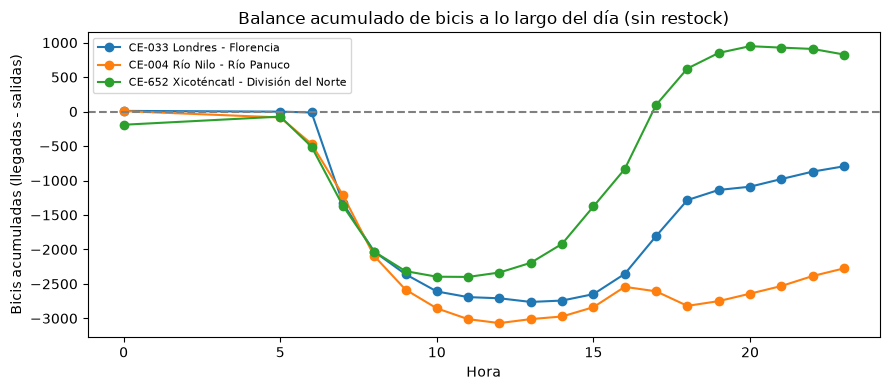

In [43]:
top_problematicas = peor_hora_por_estacion.sort_values("neto").head(3)["station_id"]

fig, ax = plt.subplots(figsize=(9, 4))
for est in top_problematicas:
    serie = flujo_hora[flujo_hora["station_id"] == est].sort_values("hora_del_dia")
    nombre = stations.set_index("station_id").loc[est, "nombre"]
    ax.plot(serie["hora_del_dia"], serie["neto"].cumsum(), marker="o", label=nombre)

ax.axhline(0, color="gray", linestyle="--")
ax.set_title("Balance acumulado de bicis a lo largo del día (sin restock)")
ax.set_xlabel("Hora")
ax.set_ylabel("Bicis acumuladas (llegadas - salidas)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../figures/curva_acumulacion.png", dpi=150)
plt.show()